# EEG_08 — TemporalChebGCN per Imagined Speech Decoding

## Architettura
Modello originale che combina:
1. **Temporal Encoder** (1D CNN per-nodo): comprime la serie temporale di ogni elettrodo in un embedding compatto
2. **ChebConv (K=2)**: convoluzione grafica su grafo di connettività funzionale
3. **Global mean pooling** + MLP classificatore

## Scelte di Design dalla Letteratura
Questo notebook prende **due scelte specifiche** da Lun et al. (2022):

> **Lun X, Jia Z, Hou Y, et al.**
> *GCNs-Net: A Graph Convolutional Neural Network Approach for Decoding Time-Resolved EEG Motor Imagery Signals*
> IEEE Transactions on Neural Systems and Rehabilitation Engineering, 2022, 30: 2447–2455.
> arXiv: [2006.08924](https://arxiv.org/abs/2006.08924)

**Scelta 1 — Grafo funzionale via PCC**: il grafo degli elettrodi è costruito calcolando la
matrice di correlazione di Pearson (|PCC|) tra canali sui dati di training, con soglia binaria.
Questo cattura la **connettività funzionale** tra elettrodi, non solo la prossimità anatomica.

**Scelta 2 — ChebConv (K=2)**: i filtri di Chebyshev al secondo ordine sono il tipo di
convoluzione grafica usato in GCNs-Net, empiricamente ottimale per EEG su grafo di elettrodi.

**Differenza rispetto a GCNs-Net**: GCNs-Net processa ogni timestep come campione indipendente
(approccio *time-resolved*, adatto a motor imagery). Qui usiamo invece un **Temporal Encoder**
(1D CNN) che processa il trial intero (384 campioni, ~1.5s), necessario per imagined speech
dove il contenuto semantico è distribuito sull'intera epoca.

## Pipeline
```
Input: grafo G per ogni trial
  Nodi V = 59 elettrodi EEG
  Archi E = coppie (i,j) con |PCC_ij| > soglia  [calcolato su dati training]
  Feature nodo = serie temporale raw (384 campioni)

[Temporal Encoder]  Conv1d(1→32, k=25) → Conv1d(32→64, k=10) → AvgPool → Linear(256→64)
[ChebConv 1]        ChebConv(64 → 128, K=2) + BN + ELU + Dropout
[ChebConv 2]        ChebConv(128 → 128, K=2) + BN + ELU
[Global MeanPool]   (batch, 128)
[MLP]               Linear(128→64) → ELU → Linear(64→n_classes)
```

## Setup
- **Split**: subject-independent — train sogg. 00-49, val 50-59, test 60-73 (identico a EEG_05)
- **Classi**: schema `ward4` (4 categorie semantiche) — chance level 25%
- **Env**: `daniele_311` (PyTorch Geometric 2.7.0)


In [25]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = True        # False → 110 parole originali
CLUSTER_SCHEME = "concr4"   # "ward4" | "ward5" | "sem5" | "pos4" | "concr4"
#                              (ignorato se USE_CLUSTERS = False)
# ───────────────────────────────────────────────────────────
K_GRAPH       = 6            # k-NN sul PCC: ogni elettrodo connesso ai k più correlati
#                              (più robusto della soglia fissa — garantisce connettività)
CHEB_K        = 2            # ordine polinomi Chebyshev (GCNs-Net: K=2 ottimale)
NODE_EMB_DIM  = 64           # embedding per nodo (dopo temporal encoder)
GCN_HIDDEN    = 128          # canali nascosti nei layer ChebConv
# ───────────────────────────────────────────────────────────
#  METODO COSTRUZIONE GRAFO — scegli uno
# ───────────────────────────────────────────────────────────
# "pcc"     → Pearson Correlation Coefficient (veloce, baseline)
# "plv"     → Phase Locking Value, banda theta+alpha 4-13Hz
# "wpli"    → Weighted Phase Lag Index (robusto a volume conduction)
# "learned" → Matrice adiacenza apprendibile end-to-end
# "dynamic" → PCC per finestra temporale (8 finestre, GPU)
GRAPH_METHOD = "dynamic"
SFREQ        = 256          # Hz — frequenza campionamento EEG
N_WINDOWS    = 8            # finestre temporali (solo per "dynamic")
PLV_BANDS    = [(4, 8), (8, 13)]           # theta + alpha (default imagined speech)
# Altre opzioni bande:
# PLV_BANDS = [(4, 8), (8, 13), (13, 30)]            # + beta (linguaggio motorio)
# PLV_BANDS = [(4, 8), (8, 13), (13, 30), (30, 80)]  # + gamma (binding semantico)
# PLV_BANDS = [(13, 30)]                              # solo beta
# PLV_BANDS = [(30, 80)]                              # solo gamma
# ═══════════════════════════════════════════════════════════


In [26]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix OpenMP su macOS

import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

# PyTorch Geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import ChebConv, global_mean_pool

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__('sys').version.split()[0])
print("torch:", torch.__version__)
import torch_geometric; print("torch_geometric:", torch_geometric.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
torch_geometric: 2.7.0


In [27]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

META_CSV  = project_root / "data" / "interim" / "eeg_metadata.csv"
ELOC_PATH = project_root / "src" / "io" / "ebneuro.locs"
GEO_CSV   = project_root / "data" / "interim" / "geodesic_D_59_channels.csv"
interim_dir = project_root / "data" / "interim"

# Parametri EEG
N_CHANS  = 59    # canali dopo rimozione A1, A2
N_TIMES  = 384   # campioni a 256 Hz (~1.5s)
SFREQ    = 256

# Training
BATCH_SIZE   = 32
MAX_EPOCHS   = 100
PATIENCE     = 15
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# Split subject-independent (identico a EEG_05)
SUBJ_TRAIN = list(range(50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

# Resume
RESUME = True

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Config OK")
print(f"project_root: {project_root}")

Config OK
project_root: /home/daniele_u/miralis-hypergraph-imagined-speech


In [28]:
# ============================================================
# METADATA + CLUSTER MAPPING
# ============================================================

import sys
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

meta = pd.read_csv(META_CSV)

# Filtro righe corrotte (epoche fuori range note)
_initial_len = len(meta)
meta = meta[~(
    (meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34))
)]
if len(meta) < _initial_len:
    print(f"Rimosse {_initial_len - len(meta)} righe corrotte.")
meta["subject_id"] = meta["subject_id"].astype(str).str.zfill(2)

# Indici canali: rimuovi A1, A2
def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]

ch_names_61 = read_eloc_names(ELOC_PATH)
EXCLUDE  = {"A1", "A2"}
keep_idx = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
keep_names = [ch_names_61[i] for i in keep_idx]
assert len(keep_idx) == N_CHANS, f"Attesi {N_CHANS} canali, trovati {len(keep_idx)}"

# Carica schema etichettatura via toggle
_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, interim_dir)

RESULTS_CSV = project_root / "data" / "interim" / f"eeg08_gcn_{N_CLASSES}_{GRAPH_METHOD}_results.csv"

print(f"Schema: {'clustering ' + CLUSTER_SCHEME if USE_CLUSTERS else '110 parole'}")
print(f"Classi: {N_CLASSES}  |  Chance level: {100/N_CLASSES:.1f}%")
print(f"Canali: {len(keep_names)} — {keep_names[:5]}...")
print(f"Totale record: {len(meta)}")

Rimosse 9 righe corrotte.
Schema: clustering concr4
Classi: 4  |  Chance level: 25.0%
Canali: 59 — ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4']...
Totale record: 39183


---
## Metodi di Costruzione del Grafo

Scegli il metodo con `GRAPH_METHOD` nella cella di configurazione.

### PCC — Pearson Correlation Coefficient (default)
Misura la **correlazione lineare di ampiezza** tra coppie di canali.
- **Pro**: veloce, semplice, ben studiato
- **Contro**: ignora la fase, ignora le frequenze, sensibile alla conduzione di volume
- Usato in: Lun et al. 2022 (GCNs-Net)

### PLV — Phase Locking Value
Misura la **sincronizzazione di fase** tra canali in una banda di frequenza specifica (theta+alpha, 4-13Hz).
- **Pro**: cattura la comunicazione oscillatoria cerebrale — cognitivamente motivato per imagined speech
- **Contro**: richiede bandpass filtering, ~3x più lento di PCC
- Banda theta (4-8Hz) + alpha (8-13Hz) attivate durante immaginazione del linguaggio
- Usato in: Duraisamy et al. 2025 (Interspeech, covert speech)

### wPLI — Weighted Phase Lag Index
Come PLV ma **rimuove la conduzione di volume** usando solo la parte immaginaria del cross-spettro.
- **Pro**: il più robusto per EEG a scalpo denso (59 canali) — connettività funzionale vera
- **Contro**: ~4x più lento di PCC
- Klepl et al. 2022: confronto empirico 8 metodi su GNN — wPLI competitivo

### Learned — Matrice adiacenza apprendibile
La struttura del grafo è un **parametro apprendibile** (matrice 59×59) aggiornata via backpropagation.
- **Pro**: il modello scopre la connettività ottimale per il task — nessuna assunzione manuale
- **Contro**: richiede più dati per convergere; modello diverso (ChebGCN_Learned)
- Ispirato a: DDGHFNet 2026 (33.2% cross-subject su imagined speech)

### Dynamic — PCC per finestra temporale
Il trial (1.5s) viene diviso in **8 finestre** (~190ms ciascuna). Ogni finestra ha il proprio grafo PCC calcolato su GPU. Un LSTM aggrega la sequenza temporale di embedding.
- **Pro**: cattura l'evoluzione della connettività durante l'immaginazione (preparazione → esecuzione)
- **Contro**: ~8x più lento per trial; modello diverso (ChebGCN_Dynamic)
- Ispirato a: DDGHFNet 2026, Li et al. 2025 (dynamic hypergraph)
---

Metodo grafo attivo: DYNAMIC
Calcolo PCC medio (solo visualizzazione)...


PCC display:   0%|          | 0/215 [00:00<?, ?it/s]

Grafo display: 59 nodi, 422 archi


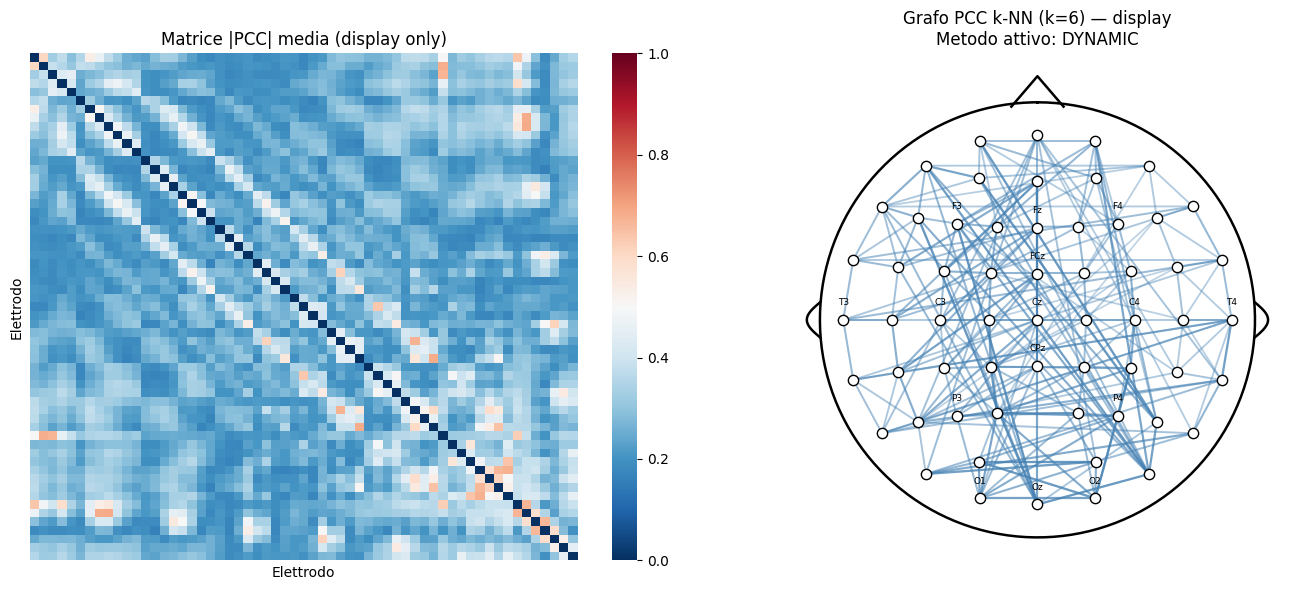

Metodo DYNAMIC: ogni trial usa build_graph_for_trial(x_np, k=6)


In [29]:
# ============================================================
# COSTRUZIONE GRAFO — funzioni per tutti i metodi
# ============================================================

from scipy.signal import butter, filtfilt
from scipy.signal import hilbert as sp_hilbert


def read_eloc_positions(eloc_path, keep_names):
    import math
    pos = {}
    with open(eloc_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            try:
                theta = float(parts[1]); radius = float(parts[2]); name = parts[3]
            except ValueError:
                continue
            if name not in keep_names:
                continue
            th = math.radians(theta)
            pos[name] = (radius * math.sin(th), radius * math.cos(th))
    return pos


def knn_from_matrix(matrix, k):
    """Converte matrice di similarità (N,N) in edge_index k-NN bidirezionale."""
    edges = set()
    for i in range(matrix.shape[0]):
        for j in np.argsort(matrix[i])[::-1][:k]:
            edges.add((i, int(j)))
            edges.add((int(j), i))
    src, dst = zip(*sorted(edges))
    return torch.tensor([list(src), list(dst)], dtype=torch.long)


# ── PCC ──────────────────────────────────────────────────────
def pcc_to_edge_index(x_np, k=6):
    """PCC k-NN per singolo trial. x_np: (n_chan, n_times)"""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return knn_from_matrix(pcc, k)


# ── PLV ──────────────────────────────────────────────────────
def plv_to_edge_index(x_np, k=6, sfreq=256, bands=None):
    """Phase Locking Value k-NN per singolo trial.
    Calcola PLV in ogni banda e fa media, poi k-NN.
    x_np: (n_chan, n_times)
    """
    if bands is None:
        bands = PLV_BANDS
    nyq = sfreq / 2.0
    plv_sum = np.zeros((x_np.shape[0], x_np.shape[0]), dtype=np.float64)
    for flo, fhi in bands:
        b, a = butter(4, [flo / nyq, fhi / nyq], btype="band")
        x_filt = filtfilt(b, a, x_np, axis=1).astype(np.float32)
        analytic = sp_hilbert(x_filt, axis=1)          # (n_chan, T) complex
        exp_phi  = np.exp(1j * np.angle(analytic))     # (n_chan, T)
        # PLV[i,j] = |mean_t(exp(i*(phi_i - phi_j)))| = |(exp_phi @ conj(exp_phi).T)| / T
        plv = np.abs(exp_phi @ exp_phi.conj().T) / x_np.shape[1]
        plv_sum += plv
    plv_matrix = (plv_sum / len(bands)).astype(np.float32)
    np.fill_diagonal(plv_matrix, 0.0)
    return knn_from_matrix(plv_matrix, k)


# ── wPLI ─────────────────────────────────────────────────────
def wpli_to_edge_index(x_np, k=6, sfreq=256, bands=None):
    """Weighted Phase Lag Index k-NN per singolo trial.
    Robusto alla conduzione di volume (usa solo parte immaginaria del cross-spettro).
    x_np: (n_chan, n_times)
    """
    if bands is None:
        bands = PLV_BANDS
    nyq = sfreq / 2.0
    wpli_sum = np.zeros((x_np.shape[0], x_np.shape[0]), dtype=np.float64)
    for flo, fhi in bands:
        b, a = butter(4, [flo / nyq, fhi / nyq], btype="band")
        x_filt  = filtfilt(b, a, x_np, axis=1).astype(np.float32)
        analytic = sp_hilbert(x_filt, axis=1)   # (n_chan, T) complex
        re = np.real(analytic)                   # (n_chan, T)
        im = np.imag(analytic)                   # (n_chan, T)
        T  = analytic.shape[1]
        # imag(C[i,j,t]) = im[i,t]*re[j,t] - re[i,t]*im[j,t]
        # Shape (n_chan, n_chan, T) — ~5MB per trial: OK
        imag_cross     = (im[:, np.newaxis, :] * re[np.newaxis, :, :]
                        - re[:, np.newaxis, :] * im[np.newaxis, :, :])
        mean_imag      = np.mean(imag_cross, axis=2)          # (n_chan, n_chan)
        mean_abs_imag  = np.mean(np.abs(imag_cross), axis=2)  # (n_chan, n_chan)
        wpli = np.abs(mean_imag) / (mean_abs_imag + 1e-8)
        wpli_sum += wpli
    wpli_matrix = (wpli_sum / len(bands)).astype(np.float32)
    np.fill_diagonal(wpli_matrix, 0.0)
    return knn_from_matrix(wpli_matrix, k)


# ── SENTINEL per learned/dynamic ─────────────────────────────
def sentinel_edge_index(n_nodes):
    """Self-loop per ogni nodo — placeholder per modelli learned/dynamic."""
    idx = torch.arange(n_nodes, dtype=torch.long)
    return torch.stack([idx, idx])


# ── DISPATCHER ───────────────────────────────────────────────
def build_graph_for_trial(x_np, k, method=GRAPH_METHOD, sfreq=SFREQ):
    """
    Costruisce edge_index per un singolo trial in base al metodo scelto.
    x_np : (n_chan, n_times) numpy array
    """
    if method == "pcc":
        return pcc_to_edge_index(x_np, k)
    elif method == "plv":
        return plv_to_edge_index(x_np, k, sfreq=sfreq)
    elif method == "wpli":
        return wpli_to_edge_index(x_np, k, sfreq=sfreq)
    elif method in ("learned", "dynamic"):
        # Questi modelli gestiscono il grafo internamente
        return sentinel_edge_index(x_np.shape[0])
    else:
        raise ValueError(f"GRAPH_METHOD sconosciuto: {method}")


# ── Visualizzazione (PCC medio — solo display) ────────────────
def compute_mean_pcc_for_display(meta_df, keep_idx, subj_train_ids, n_samples=500, seed=42):
    rng = np.random.RandomState(seed)
    train_records = meta_df[meta_df["subject_id"].isin(subj_train_ids)][["path_h5", "epoch_idx"]]
    n = min(n_samples, len(train_records))
    sampled = train_records.iloc[rng.choice(len(train_records), n, replace=False)]
    paths_map = defaultdict(list)
    for _, row in sampled.iterrows():
        paths_map[row["path_h5"]].append(int(row["epoch_idx"]))
    buf = []
    for p, epoch_idxs in tqdm(paths_map.items(), desc="PCC display", leave=False):
        with h5py.File(p, "r") as f:
            for e_idx in epoch_idxs:
                buf.append(f["data"][e_idx][keep_idx, :].astype(np.float32))
    pcc_sum = np.zeros((len(keep_idx), len(keep_idx)), dtype=np.float64)
    for x in buf:
        pcc_sum += np.abs(np.corrcoef(x))
    pcc_matrix = (pcc_sum / len(buf)).astype(np.float32)
    np.fill_diagonal(pcc_matrix, 0.0)
    return pcc_matrix


train_ids = [str(i).zfill(2) for i in SUBJ_TRAIN]
eloc_pos  = read_eloc_positions(ELOC_PATH, set(keep_names))
print(f"Metodo grafo attivo: {GRAPH_METHOD.upper()}")
print("Calcolo PCC medio (solo visualizzazione)...")
pcc_display        = compute_mean_pcc_for_display(meta, keep_idx, train_ids)
edge_index_display = knn_from_matrix(pcc_display, K_GRAPH)
print(f"Grafo display: {len(keep_idx)} nodi, {edge_index_display.shape[1]} archi")

# -- Visualizzazione topomap --
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(pcc_display, ax=axes[0], cmap="RdBu_r", vmin=0, vmax=1,
            xticklabels=False, yticklabels=False)
axes[0].set_title("Matrice |PCC| media (display only)")
axes[0].set_xlabel("Elettrodo"); axes[0].set_ylabel("Elettrodo")
ax = axes[1]
ei_np = edge_index_display.numpy()
drawn = set()
for e in range(ei_np.shape[1]):
    i, j = int(ei_np[0, e]), int(ei_np[1, e])
    if (j, i) in drawn: continue
    drawn.add((i, j))
    n1, n2 = keep_names[i], keep_names[j]
    if n1 not in eloc_pos or n2 not in eloc_pos: continue
    x1, y1 = eloc_pos[n1]; x2, y2 = eloc_pos[n2]
    w = float(pcc_display[i, j])
    ax.plot([x1, x2], [y1, y2], color="steelblue", alpha=min(w*1.2, 0.9), linewidth=1.0+w, zorder=1)
xs = [eloc_pos[n][0] for n in keep_names if n in eloc_pos]
ys = [eloc_pos[n][1] for n in keep_names if n in eloc_pos]
ax.scatter(xs, ys, s=55, c="white", edgecolors="black", linewidths=1.0, zorder=3)
landmarks = {"Fz","Cz","Pz","Oz","T3","T4","C3","C4","F3","F4","P3","P4","O1","O2","FCz","CPz"}
for name in keep_names:
    if name in eloc_pos and name in landmarks:
        x, y = eloc_pos[name]
        ax.text(x, y+0.035, name, ha="center", va="bottom", fontsize=6.5, zorder=4)
r_head = max(np.sqrt(x**2+y**2) for x, y in eloc_pos.values()) * 1.12
theta_c = np.linspace(0, 2*np.pi, 300)
ax.plot(r_head*np.sin(theta_c), r_head*np.cos(theta_c), "k-", linewidth=1.8, zorder=0)
ax.plot([-r_head*0.12, 0, r_head*0.12], [r_head*0.98, r_head*1.12, r_head*0.98], "k-", linewidth=1.8)
for sign in [-1, 1]:
    ear_y = np.linspace(-0.08, 0.08, 40) * r_head
    ear_x = sign*r_head + sign*r_head*0.06*np.cos(np.linspace(np.pi/2, -np.pi/2, 40))
    ax.plot(ear_x, ear_y, "k-", linewidth=1.8, zorder=0)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Grafo PCC k-NN (k={K_GRAPH}) — display\nMetodo attivo: {GRAPH_METHOD.upper()}")
plt.tight_layout()
plt.savefig(project_root/"figures"/f"eeg08_graph_{GRAPH_METHOD}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Metodo {GRAPH_METHOD.upper()}: ogni trial usa build_graph_for_trial(x_np, k={K_GRAPH})")

In [30]:
# ============================================================
# DATASET PyG — carica da dataset pre-costruito (EEG_07b)
# o calcola on-the-fly se il file non esiste
# ============================================================

class EEGGraphDataset(Dataset):
    """
    Dataset PyG: ogni trial EEG e' un grafo Data(x, edge_index, y).
    Carica da dataset pre-costruito da EEG_07b (dataset_{method}_k{k}.pt).
    Precomputa normalizzazione e labels in __init__ per __getitem__ O(1).
    """
    def __init__(self, data_list, labelid2cluster, mean=None, std=None):
        # ── Stats ────────────────────────────────────────────────
        if mean is None:
            rng  = np.random.RandomState(42)
            idxs = rng.choice(len(data_list), min(500, len(data_list)), replace=False)
            buf  = np.stack([data_list[i].x.numpy() for i in idxs])
            self.mean = torch.tensor(buf.mean(axis=(0,2), keepdims=True).squeeze(0), dtype=torch.float32)
            self.std  = torch.tensor(buf.std(axis=(0,2),  keepdims=True).squeeze(0).clip(1e-6), dtype=torch.float32)
            print(f"Stats OK | mean range: [{self.mean.min():.3f}, {self.mean.max():.3f}]")
        else:
            self.mean, self.std = mean, std

        # ── Precomputa tutto in RAM — __getitem__ è O(1) ─────────
        print(f"Precomputo {len(data_list)} campioni...")
        self._x    = [(d.x - self.mean) / self.std for d in data_list]
        self._edge = [d.edge_index for d in data_list]
        self._y    = [torch.tensor(labelid2cluster[int(d.y.item())], dtype=torch.long)
                      for d in data_list]
        print(f"Dataset OK: {len(self._x)} grafi")

    def __len__(self):
        return len(self._x)

    def __getitem__(self, idx):
        return Data(x=self._x[idx], edge_index=self._edge[idx], y=self._y[idx])


# ── Carica dataset pre-costruito da EEG_07b ──────────────────
def _load_dataset(method, k):
    """Carica lista Data da disco. Ritorna None se non disponibile."""
    graphs_dir = project_root / "data" / "interim" / "graphs"
    path = graphs_dir / f"dataset_{method}_k{k}.pt"
    if path.exists():
        print(f"Carico dataset pre-costruito: {path.name}...")
        dl = torch.load(path, weights_only=False)
        print(f"  {len(dl)} grafi caricati.")
        return dl
    else:
        print(f"Dataset pre-costruito non trovato ({path.name}).")
        print("  Esegui EEG_07b_precompute_graphs.ipynb prima di questo notebook.")
        return None

_PREBUILT = None
if GRAPH_METHOD in ("pcc", "plv", "wpli", "learned", "dynamic"):
    _PREBUILT = _load_dataset(GRAPH_METHOD, K_GRAPH)


def make_graph_splits(meta_df, labelid2cluster, subj_train, subj_val, subj_test, k=K_GRAPH):
    """
    Crea train/val/test EEGGraphDataset con split subject-independent.
    Usa il dataset pre-costruito da EEG_07b se disponibile.
    Stats di normalizzazione calcolate SOLO sul training set.
    """
    train_ids = {str(i).zfill(2) for i in subj_train}
    val_ids   = {str(i).zfill(2) for i in subj_val}
    test_ids  = {str(i).zfill(2) for i in subj_test}

    if _PREBUILT is None:
        # Fallback on-the-fly per tutti i metodi (quando .pt non disponibile)
        def to_records(df_sub):
            return df_sub[["path_h5", "epoch_idx", "label_idx", "subject_id"]].to_dict("records")
        r_tr = to_records(meta_df[meta_df["subject_id"].isin(train_ids)])
        r_va = to_records(meta_df[meta_df["subject_id"].isin(val_ids)])
        r_te = to_records(meta_df[meta_df["subject_id"].isin(test_ids)])
        ds_tr = EEGGraphDatasetLegacy(r_tr, keep_idx, labelid2cluster, k=k)
        ds_va = EEGGraphDatasetLegacy(r_va, keep_idx, labelid2cluster, k=k, mean=ds_tr.mean, std=ds_tr.std)
        ds_te = EEGGraphDatasetLegacy(r_te, keep_idx, labelid2cluster, k=k, mean=ds_tr.mean, std=ds_tr.std)
        print(f"Split: train={len(r_tr)} | val={len(r_va)} | test={len(r_te)}")
        print(f"Metodo={GRAPH_METHOD} | k={k} | source=on-the-fly (EEGGraphDatasetLegacy)")
        return ds_tr, ds_va, ds_te

    r_tr = [d for d in _PREBUILT if str(d.subj.item()).zfill(2) in train_ids]
    r_va = [d for d in _PREBUILT if str(d.subj.item()).zfill(2) in val_ids]
    r_te = [d for d in _PREBUILT if str(d.subj.item()).zfill(2) in test_ids]

    print(f"Split: train={len(r_tr)} | val={len(r_va)} | test={len(r_te)}")
    print(f"Metodo={GRAPH_METHOD} | k={k} | source=dataset pre-costruito")

    ds_tr = EEGGraphDataset(r_tr, labelid2cluster)
    ds_va = EEGGraphDataset(r_va, labelid2cluster, mean=ds_tr.mean, std=ds_tr.std)
    ds_te = EEGGraphDataset(r_te, labelid2cluster, mean=ds_tr.mean, std=ds_tr.std)
    return ds_tr, ds_va, ds_te


print("EEGGraphDataset (dataset pre-costruito) OK")


# ── Dataset legacy per learned/dynamic (calcola grafo on-the-fly) ──────────
class EEGGraphDatasetLegacy(Dataset):
    """Dataset on-the-fly per metodi learned/dynamic che non hanno cache pre-costruita."""
    def __init__(self, records, keep_idx, labelid2cluster, k=6, mean=None, std=None, method=None):
        self.records         = records
        self.keep_idx        = keep_idx
        self.labelid2cluster = labelid2cluster
        self.k               = k
        self.method          = method or GRAPH_METHOD  # cattura metodo al momento dell'init
        self.mean            = mean
        self.std             = std
        self.file_cache      = {}
        if mean is None:
            self._compute_stats()

    def _compute_stats(self, seed=42):
        from collections import defaultdict
        rng  = np.random.RandomState(seed)
        n    = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)
        paths_map = defaultdict(list)
        for idx in idxs:
            r = self.records[idx]
            paths_map[r["path_h5"]].append(int(r["epoch_idx"]))
        buf = []
        for path, epoch_idxs in paths_map.items():
            with h5py.File(path, "r") as f:
                for e_idx in epoch_idxs:
                    buf.append(f["data"][e_idx][self.keep_idx, :].astype(np.float32))
        buf = np.stack(buf)
        self.mean = torch.tensor(buf.mean(axis=(0,2), keepdims=True).squeeze(0), dtype=torch.float32)
        self.std  = torch.tensor(buf.std(axis=(0,2), keepdims=True).squeeze(0).clip(1e-6), dtype=torch.float32)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r    = self.records[idx]
        path = r["path_h5"]
        if path not in self.file_cache:
            self.file_cache[path] = h5py.File(path, "r")
        x_np = self.file_cache[path]["data"][int(r["epoch_idx"])][self.keep_idx, :].astype(np.float32)
        x    = (torch.tensor(x_np, dtype=torch.float32) - self.mean) / self.std
        edge_index = build_graph_for_trial(x.numpy(), k=self.k, method=self.method)
        label = self.labelid2cluster[int(r["label_idx"])]
        return Data(x=x, edge_index=edge_index, y=torch.tensor(label, dtype=torch.long))


EEGGraphDataset (dataset pre-costruito) OK


In [31]:
# ============================================================
# MODELLI — TemporalChebGCN e varianti
# Grafo PCC + ChebConv(K=2): scelte da Lun et al. 2022 (GCNs-Net)
# Temporal Encoder: contributo originale (trial interi, imagined speech)
# ============================================================

class TemporalEncoder(nn.Module):
    """
    1D CNN per-nodo (pesi condivisi tra tutti gli elettrodi).
    Estrae embedding compatto dalla serie temporale di ogni canale EEG.

    Input:  (N_nodes_total, N_TIMES)
    Output: (N_nodes_total, out_dim)
    """
    def __init__(self, n_times: int = N_TIMES, out_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=25, stride=2, padding=12),  # T/2 = 192
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 64, kernel_size=10, stride=2, padding=5),  # T/4 = 96
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(4),
            nn.Flatten(),
            nn.Linear(256, out_dim),
            nn.ELU(),
        )

    def forward(self, x):
        return self.net(x.unsqueeze(1))  # (N_nodes_total, out_dim)


class TemporalChebGCN(nn.Module):
    """
    TemporalChebGCN per imagined speech decoding (59 canali, trial interi).

    Design:
    - Temporal Encoder (1D CNN per-nodo): estrae embedding compatto da 384 timestep
    - ChebConv(K=2): convoluzione grafica spettrale su grafo PCC — da Lun et al. 2022
    - global_mean_pool + MLP: classificatore graph-level

    Nota: GCNs-Net (Lun et al., 2022) usa processing time-resolved (ogni timestep
    come campione separato). Il Temporal Encoder qui è una scelta originale,
    necessaria perché classifichiamo trial interi, non singoli timestep.

    Riferimento grafo+conv: Lun X et al., IEEE TNSRE 2022, arXiv:2006.08924
    """
    def __init__(self, n_times=N_TIMES, node_emb=NODE_EMB_DIM, gcn_hidden=GCN_HIDDEN,
                 n_classes=4, dropout=0.5, cheb_k=CHEB_K):
        super().__init__()
        self.temporal = TemporalEncoder(n_times, node_emb)
        self.conv1    = ChebConv(node_emb,   gcn_hidden, K=cheb_k)
        self.conv2    = ChebConv(gcn_hidden, gcn_hidden, K=cheb_k)
        self.drop     = nn.Dropout(dropout)
        self.bn1      = nn.BatchNorm1d(gcn_hidden)
        self.bn2      = nn.BatchNorm1d(gcn_hidden)
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 64),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.temporal(x)                            # (N, node_emb)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))  # ChebConv 1
        x = self.drop(x)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))  # ChebConv 2
        x = global_mean_pool(x, batch)                  # (batch, gcn_hidden)
        return self.classifier(x)


class TemporalChebGCN3L(nn.Module):
    # Variante con 3 layer ChebConv (K=2)
    def __init__(self, n_times=N_TIMES, node_emb=NODE_EMB_DIM, gcn_hidden=GCN_HIDDEN,
                 n_classes=4, dropout=0.5, cheb_k=CHEB_K):
        super().__init__()
        self.temporal = TemporalEncoder(n_times, node_emb)
        self.conv1 = ChebConv(node_emb,   gcn_hidden, K=cheb_k)
        self.conv2 = ChebConv(gcn_hidden, gcn_hidden, K=cheb_k)
        self.conv3 = ChebConv(gcn_hidden, gcn_hidden, K=cheb_k)
        self.drop  = nn.Dropout(dropout)
        self.bn1   = nn.BatchNorm1d(gcn_hidden)
        self.bn2   = nn.BatchNorm1d(gcn_hidden)
        self.bn3   = nn.BatchNorm1d(gcn_hidden)
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 64), nn.ELU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.temporal(x)
        x = F.elu(self.bn1(self.conv1(x, edge_index))); x = self.drop(x)
        x = F.elu(self.bn2(self.conv2(x, edge_index))); x = self.drop(x)
        x = F.elu(self.bn3(self.conv3(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.classifier(x)


class TemporalChebGCNSkip(nn.Module):
    # Variante con skip connection residuale tra layer ChebConv
    def __init__(self, n_times=N_TIMES, node_emb=NODE_EMB_DIM, gcn_hidden=GCN_HIDDEN,
                 n_classes=4, dropout=0.5, cheb_k=CHEB_K):
        super().__init__()
        self.temporal = TemporalEncoder(n_times, node_emb)
        self.proj  = nn.Linear(node_emb, gcn_hidden)
        self.conv1 = ChebConv(node_emb,   gcn_hidden, K=cheb_k)
        self.conv2 = ChebConv(gcn_hidden, gcn_hidden, K=cheb_k)
        self.drop  = nn.Dropout(dropout)
        self.bn1   = nn.BatchNorm1d(gcn_hidden)
        self.bn2   = nn.BatchNorm1d(gcn_hidden)
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 64), nn.ELU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        h    = self.temporal(x)
        skip = self.proj(h)
        h = F.elu(self.bn1(self.conv1(h, edge_index)))
        h = self.drop(h)
        h = F.elu(self.bn2(self.conv2(h, edge_index) + skip))
        h = global_mean_pool(h, batch)
        return self.classifier(h)




class ChebGCN_Learned(nn.Module):
    """
    ChebGCN con matrice di adiacenza APPRENDIBILE end-to-end.
    A (59x59) e un parametro del modello aggiornato via backprop.
    Ignora data.edge_index — costruisce il proprio grafo da A_raw.
    Ispirato a: DDGHFNet 2026 (33.2% cross-subject su imagined speech).
    """
    def __init__(self, n_times=N_TIMES, node_emb=NODE_EMB_DIM, gcn_hidden=GCN_HIDDEN,
                 n_classes=4, dropout=0.5, cheb_k=CHEB_K):
        super().__init__()
        self.k       = K_GRAPH
        self.temporal = TemporalEncoder(n_times, node_emb)
        # Matrice adiacenza apprendibile (simmetrica, non-negativa)
        self.A_raw   = nn.Parameter(torch.randn(N_CHANS, N_CHANS) * 0.01)
        self.conv1   = ChebConv(node_emb,   gcn_hidden, K=cheb_k)
        self.conv2   = ChebConv(gcn_hidden, gcn_hidden, K=cheb_k)
        self.drop    = nn.Dropout(dropout)
        self.bn1     = nn.BatchNorm1d(gcn_hidden)
        self.bn2     = nn.BatchNorm1d(gcn_hidden)
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 64), nn.ELU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def _build_edge_index(self, batch):
        """Costruisce edge_index dalla matrice apprendibile A_raw."""
        # Rendi A simmetrica e non-negativa
        A = torch.sigmoid((self.A_raw + self.A_raw.T) / 2)
        A = A * (1 - torch.eye(N_CHANS, device=A.device))  # no self-loop
        # Top-k per riga
        _, topk_idx = torch.topk(A, self.k, dim=1)          # (N_CHANS, k)
        src = torch.arange(N_CHANS, device=A.device).repeat_interleave(self.k)
        dst = topk_idx.reshape(-1)
        src_bi = torch.cat([src, dst])
        dst_bi = torch.cat([dst, src])
        base_ei = torch.stack([src_bi, dst_bi])              # (2, 2*N*k)
        # Replica per ogni grafo nel batch
        B_size = int(batch.max().item()) + 1
        edge_indices = []
        for g in range(B_size):
            offset = int((batch == g).nonzero()[0].item())
            edge_indices.append(base_ei + offset)
        return torch.cat(edge_indices, dim=1)

    def forward(self, data):
        x, batch = data.x, data.batch
        x  = self.temporal(x)
        ei = self._build_edge_index(batch)
        x  = F.elu(self.bn1(self.conv1(x, ei))); x = self.drop(x)
        x  = F.elu(self.bn2(self.conv2(x, ei)))
        x  = global_mean_pool(x, batch)
        return self.classifier(x)


class ChebGCN_Dynamic(nn.Module):
    """
    GCN con grafo dinamico per finestra temporale.
    Il trial (59, T) viene diviso in N_WINDOWS finestre.
    Per ogni finestra: PCC GPU -> grafo -> ChebConv -> embedding.
    Un LSTM aggrega la sequenza temporale di embedding.
    Ispirato a: DDGHFNet 2026, Li et al. 2025 (dynamic hypergraph).
    """
    def __init__(self, n_times=N_TIMES, node_emb=NODE_EMB_DIM, gcn_hidden=GCN_HIDDEN,
                 n_classes=4, dropout=0.5, cheb_k=CHEB_K, n_windows=N_WINDOWS):
        super().__init__()
        self.n_windows = n_windows
        self.k         = K_GRAPH
        self.temporal  = TemporalEncoder(n_times // n_windows, node_emb)
        self.conv1     = ChebConv(node_emb,   gcn_hidden, K=cheb_k)
        self.conv2     = ChebConv(gcn_hidden, gcn_hidden, K=cheb_k)
        self.drop      = nn.Dropout(dropout)
        self.bn1       = nn.BatchNorm1d(gcn_hidden)
        self.bn2       = nn.BatchNorm1d(gcn_hidden)
        self.lstm      = nn.LSTM(gcn_hidden, gcn_hidden, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 64), nn.ELU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    @staticmethod
    def _pcc_gpu(x):
        """PCC su GPU. x: (N_nodes, T) -> (N_nodes, N_nodes)"""
        x = x - x.mean(dim=1, keepdim=True)
        x = x / (x.std(dim=1, keepdim=True).clamp(min=1e-8))
        return (x @ x.T / x.shape[1]).abs()

    def _window_edge_index(self, x_win, batch):
        """Costruisce edge_index da PCC della finestra corrente (GPU)."""
        B_size = int(batch.max().item()) + 1
        edge_indices = []
        for g in range(B_size):
            mask   = (batch == g)
            x_g    = x_win[mask]                               # (N_CHANS, win_size)
            pcc    = self._pcc_gpu(x_g)
            pcc.fill_diagonal_(0.0)
            _, topk_idx = torch.topk(pcc, self.k, dim=1)
            N   = x_g.shape[0]
            src = torch.arange(N, device=x_g.device).repeat_interleave(self.k)
            dst = topk_idx.reshape(-1)
            ei  = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])])
            offset = int(mask.nonzero()[0].item())
            edge_indices.append(ei + offset)
        return torch.cat(edge_indices, dim=1)

    def forward(self, data):
        x, batch = data.x, data.batch      # x: (N_total, T)
        T        = x.shape[1]
        win_size = T // self.n_windows
        window_embs = []
        for w in range(self.n_windows):
            x_win = x[:, w * win_size:(w + 1) * win_size]     # (N_total, win_size)
            x_enc = self.temporal(x_win)                       # (N_total, node_emb)
            ei    = self._window_edge_index(x_win, batch)
            h     = F.elu(self.bn1(self.conv1(x_enc, ei)))
            h     = self.drop(h)
            h     = F.elu(self.bn2(self.conv2(h, ei)))
            h_pool = global_mean_pool(h, batch)                # (B, gcn_hidden)
            window_embs.append(h_pool)
        seq = torch.stack(window_embs, dim=1)                  # (B, n_win, gcn_hidden)
        _, (h_last, _) = self.lstm(seq)
        h_last = h_last.squeeze(0)                             # (B, gcn_hidden)
        return self.classifier(h_last)

# Factory — seleziona modelli in base al metodo grafo
if GRAPH_METHOD in ("pcc", "plv", "wpli"):
    GCN_MODELS = {
        "ChebGCN_2L":  lambda nc: TemporalChebGCN(n_classes=nc),
        "ChebGCN_3L":  lambda nc: TemporalChebGCN3L(n_classes=nc),
        "ChebGCNSkip": lambda nc: TemporalChebGCNSkip(n_classes=nc),
    }
elif GRAPH_METHOD == "learned":
    GCN_MODELS = {
        "ChebGCN_Learned": lambda nc: ChebGCN_Learned(n_classes=nc),
    }
elif GRAPH_METHOD == "dynamic":
    GCN_MODELS = {
        "ChebGCN_Dynamic": lambda nc: ChebGCN_Dynamic(n_classes=nc),
    }

print(f"Metodo: {GRAPH_METHOD.upper()} | Modelli attivi: {list(GCN_MODELS.keys())}")
print(f"{'Modello':<25} {'Parametri':>12}")
print("-" * 39)
for name, factory in GCN_MODELS.items():
    m = factory(4)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<25} {n_params:>12,}")

Metodo: DYNAMIC | Modelli attivi: ['ChebGCN_Dynamic']
Modello                      Parametri
---------------------------------------
ChebGCN_Dynamic                228,548


In [32]:
# ============================================================
# TRAINING + VALUTAZIONE (PyG)
# ============================================================

def train_gcn(model, ds_train, ds_val, save_path, tb_dir,
              n_epochs=MAX_EPOCHS, patience=PATIENCE,
              lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE):
    """
    Training con early stopping su val_bacc e checkpoint.
    Restituisce (model, history_dict, n_epochs_trained).
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    # Calcola class weights dal training set (inversamente proporzionali alla frequenza)
    # Supporta sia EEGGraphDataset (data_list) che EEGGraphDatasetLegacy (records)
    if hasattr(ds_train, "data_list"):
        all_labels = [ds_train.labelid2cluster[int(d.y.item())] for d in ds_train.data_list]
    else:
        all_labels = [ds_train.labelid2cluster[int(r["label_idx"])] for r in ds_train.records]
    counts = torch.bincount(torch.tensor(all_labels), minlength=N_CLASSES).float()
    class_weights = (1.0 / counts.clamp(min=1))
    class_weights = (class_weights / class_weights.sum() * N_CLASSES).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    writer    = SummaryWriter(log_dir=str(tb_dir))

    loader_tr = PyGDataLoader(ds_train, batch_size=batch_size, shuffle=True)
    loader_va = PyGDataLoader(ds_val,   batch_size=batch_size, shuffle=False)

    best_val_bacc = -1.0
    best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    patience_cnt  = 0
    history       = defaultdict(list)

    for epoch in range(n_epochs):
        # ── Fase di training ──
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        pbar = tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)
        for data in pbar:
            data = data.to(device)
            optimizer.zero_grad()
            logits = model(data)
            loss   = criterion(logits, data.y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(data.y)
            correct  += (logits.argmax(1) == data.y).sum().item()
            n_tot    += len(data.y)
            pbar.set_postfix(loss=f"{loss.item():.3f}")
        scheduler.step()

        # ── Fase di validazione ──
        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for data in loader_va:
                data = data.to(device)
                ps_v.extend(model(data).argmax(1).cpu().tolist())
                ys_v.extend(data.y.cpu().tolist())

        val_acc   = accuracy_score(ys_v, ps_v)
        val_bacc  = balanced_accuracy_score(ys_v, ps_v)
        train_acc = correct / n_tot if n_tot > 0 else 0.0
        train_loss_avg = loss_sum / n_tot if n_tot > 0 else 0.0

        history["val_acc"].append(val_acc)
        history["val_bacc"].append(val_bacc)
        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss_avg)

        writer.add_scalar("val/acc",    val_acc,   epoch)
        writer.add_scalar("val/bacc",   val_bacc,  epoch)
        writer.add_scalar("train/acc",  train_acc, epoch)
        writer.add_scalar("train/loss", train_loss_avg, epoch)

        # ── Early stopping su val_bacc ──
        if val_bacc > best_val_bacc:
            best_val_bacc = val_bacc
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
            save_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"    Early stop @ epoch {epoch+1} (best val_bacc={best_val_bacc:.3f})")
                break

    writer.close()
    model.load_state_dict(best_state)
    return model, dict(history), epoch + 1


def evaluate_gcn(model, ds, batch_size=64):
    """Calcola acc e bacc su un dataset PyG."""
    loader = PyGDataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            ps.extend(model(data).argmax(1).cpu().tolist())
            ys.extend(data.y.cpu().tolist())
    return {
        "acc":  accuracy_score(ys, ps),
        "bacc": balanced_accuracy_score(ys, ps),
    }


print("Funzioni training OK")

Funzioni training OK


In [33]:
# ============================================================
# SANITY CHECK — forward pass su un mini-batch
# ============================================================

print("=== Sanity check forward pass ===")

if _PREBUILT is None:
    print("SKIP: dataset pre-costruito non disponibile. Esegui EEG_07b prima.")
else:
    # Usa i primi 10 Data dal dataset pre-costruito
    ds_sample    = EEGGraphDataset(_PREBUILT[:10], labelid2cluster)
    sample_loader = PyGDataLoader(ds_sample, batch_size=4, shuffle=False)
    batch_sample  = next(iter(sample_loader))

    print(f"Batch x shape:      {batch_sample.x.shape}     # (4x59, 384)")
    print(f"Batch edge_index:   {batch_sample.edge_index.shape}   # per-trial, diverso per ogni grafo")
    print(f"Batch y:            {batch_sample.y}")
    print(f"Batch batch tensor: {batch_sample.batch[:10]}...")

    # Test su ogni modello
    for mname, factory in GCN_MODELS.items():
        model_test = factory(N_CLASSES).to(device)
        model_test.eval()
        with torch.no_grad():
            out = model_test(batch_sample.to(device))
        print(f"{mname:<22} output: {out.shape}  OK")

    print("\nSanity check OK")


=== Sanity check forward pass ===
SKIP: dataset pre-costruito non disponibile. Esegui EEG_07b prima.


In [34]:
# ============================================================
# ESPERIMENTO — GCN Subject-Independent
# ============================================================

chance_level = 1.0 / N_CLASSES
NORM_TAG     = "_norm" if USE_CLUSTERS else ""

TB_BASE   = project_root / "runs"   / f"eeg08_gcn_{N_CLASSES}_{GRAPH_METHOD}"
CKPT_BASE = project_root / "models" / f"eeg08_gcn_{N_CLASSES}_{GRAPH_METHOD}"
CKPT_BASE.mkdir(parents=True, exist_ok=True)

# ── Carica risultati già salvati (resume) ──
if RESUME and RESULTS_CSV.exists():
    df_existing = pd.read_csv(RESULTS_CSV)
    done_models = set(df_existing["model"].tolist())
    results_gcn = df_existing.to_dict("records")
    print(f"Resume: trovati {len(done_models)} modelli già completati: {done_models}")
else:
    done_models = set()
    results_gcn = []

# ── Split dataset ──
print("\nCreazione split subject-independent...")
ds_tr, ds_va, ds_te = make_graph_splits(
    meta, labelid2cluster, SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST
)
print(f"Split OK | tr={len(ds_tr)} va={len(ds_va)} te={len(ds_te)}")

# ── Loop principale ──
print(f"\n── GCN Subject-Independent │ {N_CLASSES} classi │ {GRAPH_METHOD.upper()} k={K_GRAPH} ──")
print(f"   Chance level: {chance_level:.1%}")
print()

for mname, factory in GCN_MODELS.items():
    if mname in done_models:
        print(f"  {mname:<22} ⏭ già completato")
        continue

    t0 = time.time()
    save_path = CKPT_BASE / f"{mname}.pth"
    tb_dir    = TB_BASE / mname

    model = factory(N_CLASSES)
    model, hist, n_ep = train_gcn(model, ds_tr, ds_va, save_path, tb_dir)

    va_r = evaluate_gcn(model, ds_va)
    te_r = evaluate_gcn(model, ds_te)
    elapsed = time.time() - t0

    # Log metriche test su TensorBoard (punto singolo all epoch finale)
    with SummaryWriter(log_dir=str(tb_dir)) as w:
        w.add_scalar("test/acc",  te_r["acc"],  n_ep)
        w.add_scalar("test/bacc", te_r["bacc"], n_ep)

    row = dict(
        model    = mname,
        val_acc  = va_r["acc"],
        val_bacc = va_r["bacc"],
        test_acc = te_r["acc"],
        test_bacc= te_r["bacc"],
        epochs   = n_ep,
        time_s   = round(elapsed, 1),
        k_graph = K_GRAPH,
        node_emb    = NODE_EMB_DIM,
        gcn_hidden  = GCN_HIDDEN,
        n_classes   = N_CLASSES,
    )
    results_gcn.append(row)
    done_models.add(mname)

    # Salva dopo ogni modello (resume-safe)
    pd.DataFrame(results_gcn).to_csv(RESULTS_CSV, index=False)

    print(f"  {mname:<22} val={va_r['acc']:.3f}  test={te_r['acc']:.3f}  "
          f"bacc={te_r['bacc']:.3f}  ({n_ep}ep {elapsed:.0f}s)")

print(f"\n✓ Completato  (chance={chance_level:.1%})")


Creazione split subject-independent...
Split: train=26166 | val=5500 | test=7260
Metodo=dynamic | k=6 | source=on-the-fly
Split OK | tr=26166 va=5500 te=7260

── GCN Subject-Independent │ 4 classi │ DYNAMIC k=6 ──
   Chance level: 25.0%



Epoch 1/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/818 [00:00<?, ?it/s]

...

Epoch 14/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 15/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 16/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 17/100:   0%|          | 0/818 [00:00<?, ?it/s]

    Early stop @ epoch 17 (best val_bacc=0.250)
  ChebGCN_Dynamic        val=0.246  test=0.248  bacc=0.248  (17ep 7411s)

✓ Completato  (chance=25.0%)


In [35]:
# ============================================================
# RISULTATI E VISUALIZZAZIONE
# ============================================================

df_gcn = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(results_gcn)
chance = 1.0 / N_CLASSES

print(f"\n═══════════════════════════════════════════════")
print(f"  EEG_08 — GCN Spaziale | {N_CLASSES} classi | k={K_GRAPH}")
print(f"  Chance level: {chance:.1%}")
print(f"═══════════════════════════════════════════════")
print(df_gcn[["model", "val_acc", "val_bacc", "test_acc", "test_bacc", "epochs"]].to_string(index=False))

best_row = df_gcn.sort_values("test_bacc", ascending=False).iloc[0]
print(f"\n► Miglior modello: {best_row['model']}")
print(f"  val_bacc={best_row['val_bacc']:.3f}  test_bacc={best_row['test_bacc']:.3f}")
print(f"  Ratio vs chance: {best_row['test_bacc']/chance:.2f}x")


═══════════════════════════════════════════════
  EEG_08 — GCN Spaziale | 4 classi | k=6
  Chance level: 25.0%
═══════════════════════════════════════════════
          model  val_acc  val_bacc  test_acc  test_bacc  epochs
ChebGCN_Dynamic 0.246364  0.250139  0.248072   0.248492      17

► Miglior modello: ChebGCN_Dynamic
  val_bacc=0.250  test_bacc=0.248
  Ratio vs chance: 0.99x


Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_gcn_4_results.png


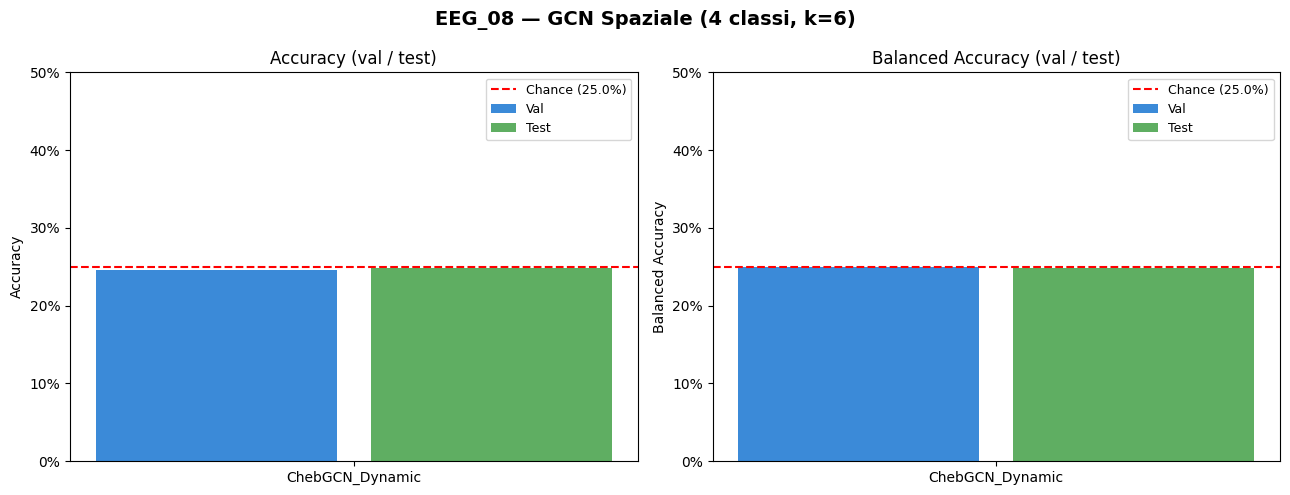

In [36]:
# ============================================================
# BAR CHART — confronto modelli GCN + EEGNet baseline
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"EEG_08 — GCN Spaziale ({N_CLASSES} classi, k={K_GRAPH})", fontsize=14, fontweight="bold")

colors_model = ["#1565C0", "#2E7D32", "#6A1B9A"]
models_order = list(GCN_MODELS.keys())

# ── Accuracy panel ──
ax = axes[0]
x = np.arange(len(models_order))
df_plot = df_gcn.set_index("model").reindex(models_order)

bars_val  = ax.bar(x - 0.2, df_plot["val_acc"],  0.35, label="Val",  color="#1976D2", alpha=0.85)
bars_test = ax.bar(x + 0.2, df_plot["test_acc"], 0.35, label="Test", color="#43A047", alpha=0.85)
ax.axhline(chance, color="red", linestyle="--", linewidth=1.5, label=f"Chance ({chance:.1%})")
ax.set_xticks(x); ax.set_xticklabels([m.replace("Temporal", "T\n") for m in models_order], fontsize=10)
ax.set_ylabel("Accuracy"); ax.set_title("Accuracy (val / test)")
ax.legend(fontsize=9); ax.set_ylim(0, max(0.5, df_gcn["test_acc"].max() + 0.05))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

# ── Balanced accuracy panel ──
ax = axes[1]
bars_val2  = ax.bar(x - 0.2, df_plot["val_bacc"],  0.35, label="Val",  color="#1976D2", alpha=0.85)
bars_test2 = ax.bar(x + 0.2, df_plot["test_bacc"], 0.35, label="Test", color="#43A047", alpha=0.85)
ax.axhline(chance, color="red", linestyle="--", linewidth=1.5, label=f"Chance ({chance:.1%})")
ax.set_xticks(x); ax.set_xticklabels([m.replace("Temporal", "T\n") for m in models_order], fontsize=10)
ax.set_ylabel("Balanced Accuracy"); ax.set_title("Balanced Accuracy (val / test)")
ax.legend(fontsize=9); ax.set_ylim(0, max(0.5, df_gcn["test_bacc"].max() + 0.05))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

plt.tight_layout()

fig_path = project_root / "figures" / f"eeg08_gcn_{N_CLASSES}_results.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Salvato: {fig_path}")
plt.show()

Confusion matrix per: ChebGCN_Dynamic


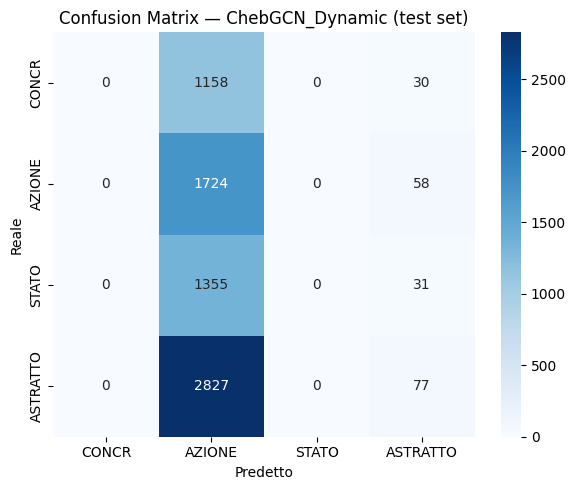

In [37]:
# ============================================================
# CONFUSION MATRIX — modello migliore su test set
# ============================================================

best_model_name = df_gcn.sort_values("test_bacc", ascending=False).iloc[0]["model"]
print(f"Confusion matrix per: {best_model_name}")

# Ricarica il modello best
best_model = GCN_MODELS[best_model_name](N_CLASSES)
ckpt_path  = CKPT_BASE / f"{best_model_name}.pth"
if ckpt_path.exists():
    best_model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    best_model = best_model.to(device)
    
    loader_te = PyGDataLoader(ds_te, batch_size=64, shuffle=False)
    best_model.eval()
    ys_all, ps_all = [], []
    with torch.no_grad():
        for data in loader_te:
            data = data.to(device)
            ps_all.extend(best_model(data).argmax(1).cpu().tolist())
            ys_all.extend(data.y.cpu().tolist())
    
    cm = confusion_matrix(ys_all, ps_all)
    class_labels = [cluster_names.get(i, f"C{i}") for i in range(N_CLASSES)]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels, ax=ax
    )
    ax.set_xlabel("Predetto"); ax.set_ylabel("Reale")
    ax.set_title(f"Confusion Matrix — {best_model_name} (test set)")
    plt.tight_layout()
    plt.savefig(project_root / "figures" / f"eeg08_cm_{best_model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Checkpoint non trovato: {ckpt_path}")

In [38]:
# ============================================================
# [OPZIONALE] HYPERPARAMETER TUNING — Optuna
# Esegui questa cella solo dopo aver verificato che il modello
# funziona e supera chance. Ottimizza su val_bacc.
# ============================================================
# pip install optuna (se non installato)

RUN_OPTUNA = False   # ← cambia a True per avviare il tuning
N_TRIALS   = 30      # numero di trial Optuna

if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        # Spazio di ricerca degli iperparametri
        threshold  = trial.suggest_float("pcc_threshold", 0.3, 0.7, step=0.1)
        cheb_k     = trial.suggest_int("cheb_k", 1, 3)
        node_emb   = trial.suggest_categorical("node_emb_dim", [32, 64, 128])
        gcn_hidden = trial.suggest_categorical("gcn_hidden",   [64, 128, 256])
        dropout    = trial.suggest_float("dropout", 0.3, 0.6, step=0.1)

        # Ricostruisce grafo con la soglia PCC proposta
        ei, _ = compute_pcc_graph(
            meta, keep_idx, [str(i).zfill(2) for i in SUBJ_TRAIN],
            threshold=threshold, n_samples=500
        )
        if ei.shape[1] == 0:
            return 0.0  # grafo vuoto: scarta

        # Ricostruisce dataset con nuovo edge_index
        ds_tr_opt = EEGGraphDataset(
            meta[meta["subject_id"].isin([str(i).zfill(2) for i in SUBJ_TRAIN])][["path_h5","epoch_idx","label_idx"]].to_dict("records"),
            keep_idx, labelid2cluster, ei
        )
        ds_va_opt = EEGGraphDataset(
            meta[meta["subject_id"].isin([str(i).zfill(2) for i in SUBJ_VAL])][["path_h5","epoch_idx","label_idx"]].to_dict("records"),
            keep_idx, labelid2cluster, ei, mean=ds_tr_opt.mean, std=ds_tr_opt.std
        )

        model = TemporalChebGCN(
            node_emb=node_emb, gcn_hidden=gcn_hidden,
            n_classes=N_CLASSES, dropout=dropout, cheb_k=cheb_k
        )
        ckpt = CKPT_BASE / f"optuna_trial_{trial.number}.pth"
        tb   = TB_BASE / f"optuna_trial_{trial.number}"
        _, hist, _ = train_gcn(model, ds_tr_opt, ds_va_opt, ckpt, tb,
                               n_epochs=50, patience=10)  # epoche ridotte per velocità
        return max(hist["val_bacc"]) if hist["val_bacc"] else 0.0

    study = optuna.create_study(direction="maximize",
                                study_name=f"eeg08_gcn_{N_CLASSES}cls")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f"\nBest trial: {study.best_trial.number}")
    print(f"Best val_bacc: {study.best_value:.4f}")
    print(f"Best params:   {study.best_params}")

    # Visualizzazione importanza parametri
    try:
        fig = optuna.visualization.plot_param_importances(study)
        fig.show()
        fig2 = optuna.visualization.plot_optimization_history(study)
        fig2.show()
    except Exception:
        pass
else:
    print("Optuna disabilitato — imposta RUN_OPTUNA = True per avviare il tuning.")
    print("Consiglio: esegui prima il loop principale (cella precedente) e verifica")
    print("che almeno un modello superi chance prima di fare hyperparameter search.")


Optuna disabilitato — imposta RUN_OPTUNA = True per avviare il tuning.
Consiglio: esegui prima il loop principale (cella precedente) e verifica
che almeno un modello superi chance prima di fare hyperparameter search.


In [ ]:
# ============================================================
# ABLATION LOOP — esegue tutti i metodi in sequenza
# Imposta RUN_ALL_METHODS = True per runnare l'ablation completo.
# I risultati per ogni metodo vengono salvati in CSV separati.
# ============================================================

RUN_ALL_METHODS = True   # ← True per ablation completo, False per singolo metodo (GRAPH_METHOD)

ALL_METHODS = ["pcc", "plv", "wpli", "learned", "dynamic"]

if RUN_ALL_METHODS:
    all_results = []

    for _method in ALL_METHODS:
        print(f"\n{'='*60}")
        print(f"  METODO: {_method.upper()}  ({ALL_METHODS.index(_method)+1}/{len(ALL_METHODS)})")
        print(f"{'='*60}")

        # ── Aggiorna globals ────────────────────────────────────
        import builtins
        globals()["GRAPH_METHOD"] = _method
        globals()["_PREBUILT"]    = _load_dataset(_method, K_GRAPH)

        _results_csv = project_root / "data" / "interim" / f"eeg08_gcn_{N_CLASSES}_{_method}_results.csv"
        _tb_base     = project_root / "runs"   / f"eeg08_gcn_{N_CLASSES}_{_method}"
        _ckpt_base   = project_root / "models" / f"eeg08_gcn_{N_CLASSES}_{_method}"
        _ckpt_base.mkdir(parents=True, exist_ok=True)

        # ── Resume ──────────────────────────────────────────────
        if RESUME and _results_csv.exists():
            _df = pd.read_csv(_results_csv)
            _done = set(_df["model"].tolist())
            _rows = _df.to_dict("records")
            print(f"  Resume: {len(_done)} modelli già completati: {_done}")
        else:
            _done = set()
            _rows = []

        # ── Split ────────────────────────────────────────────────
        ds_tr, ds_va, ds_te = make_graph_splits(meta, labelid2cluster, SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST)
        print(f"  Split OK | tr={len(ds_tr)} va={len(ds_va)} te={len(ds_te)}")
        print(f"  Chance level: {1/N_CLASSES:.1%}")

        # ── Loop modelli ─────────────────────────────────────────
        for mname, factory in GCN_MODELS.items():
            if mname in _done:
                print(f"  {mname:<22} ⏭ già completato")
                continue

            t0 = time.time()
            save_path = _ckpt_base / f"{mname}.pth"
            tb_dir    = _tb_base / mname

            model = factory(N_CLASSES)
            model, hist, n_ep = train_gcn(model, ds_tr, ds_va, save_path, tb_dir)

            va_r = evaluate_gcn(model, ds_va)
            te_r = evaluate_gcn(model, ds_te)
            elapsed = time.time() - t0

            with SummaryWriter(log_dir=str(tb_dir)) as w:
                w.add_scalar("test/acc",  te_r["acc"],  n_ep)
                w.add_scalar("test/bacc", te_r["bacc"], n_ep)

            row = dict(
                method   = _method,
                model    = mname,
                val_acc  = va_r["acc"],
                val_bacc = va_r["bacc"],
                test_acc = te_r["acc"],
                test_bacc= te_r["bacc"],
                epochs   = n_ep,
                time_s   = round(elapsed, 1),
                k_graph  = K_GRAPH,
                n_classes= N_CLASSES,
            )
            _rows.append(row)
            _done.add(mname)
            pd.DataFrame(_rows).to_csv(_results_csv, index=False)
            all_results.append(row)
            print(f"  {mname:<22} val_bacc={va_r['bacc']:.3f}  test_bacc={te_r['bacc']:.3f}  ({n_ep}ep {elapsed:.0f}s)")

    # ── Riepilogo finale ─────────────────────────────────────────
    print(f"\n{'='*60}")
    print("  RIEPILOGO ABLATION")
    print(f"{'='*60}")
    df_all = pd.DataFrame(all_results)
    _combined_csv = project_root / "data" / "interim" / f"eeg08_ablation_{N_CLASSES}_results.csv"
    df_all.to_csv(_combined_csv, index=False)
    print(df_all.groupby(["method","model"])[["val_bacc","test_bacc"]].mean().round(3).to_string())
    print(f"\nRisultati salvati: {_combined_csv.name}")
    print(f"Chance level: {1/N_CLASSES:.1%}")
